In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from scipy.sparse.linalg import spsolve

Mass matrix initialization completed
Stiffness matrix initialization completed


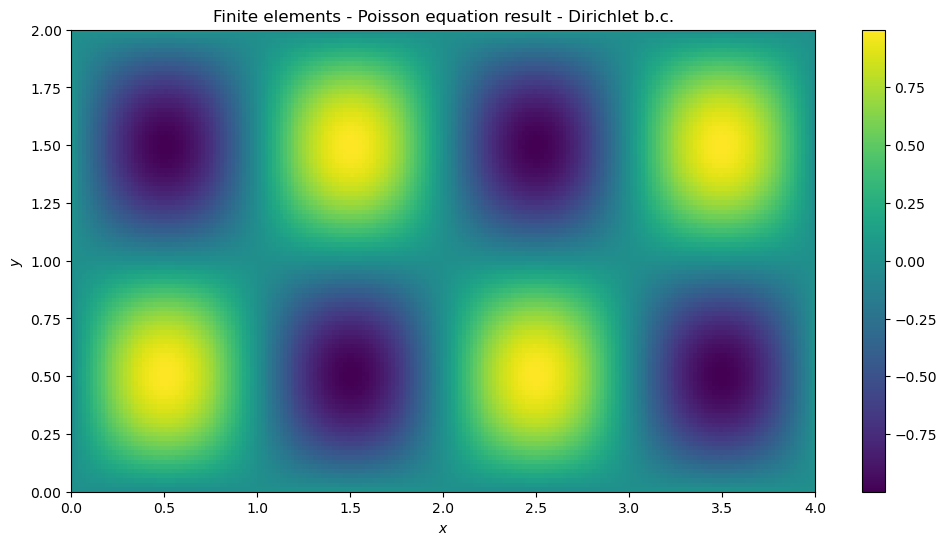

In [2]:
# As a reference solution, first compute the solution with the finite elements methods

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

func = lambda x,y: 2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
diri = lambda x,y: 0
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

plt.figure(figsize=(12, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson.png')


In [3]:
# Example of a basic case for automatic differentiation with PyTorch

x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()
# y.backward() saves the gradient back on x. Note that backward destryos the graph, so if I want to apply the graph another time I have to add retain_graph = True
print(x.grad)

tensor(6.)


In [4]:
f_poisson_torch = lambda x: 2.0 * torch.pi**2 * torch.sin(torch.pi * x[:, 0:1]) * torch.sin(torch.pi * x[:, 1:2])

trial_PINN = PINN_Poisson_2d(32, f_poisson_torch, lambda x: 0)
# attention, the Dirichlet and Poisson functions take lists [x, y] as inputs
trial_PINN.set_collocation_points(400, (0,4), (0,2))
trial_PINN.compute_boundary_values(100, (0,4), (0,2))

trial_PINN.train(100000)

Epoch [1000/100000], Loss: 0.0228
Epoch [2000/100000], Loss: 0.0156
Epoch [3000/100000], Loss: 0.0241
Epoch [4000/100000], Loss: 0.0287
Epoch [5000/100000], Loss: 0.0091
Epoch [6000/100000], Loss: 0.0266
Epoch [7000/100000], Loss: 0.0108
Epoch [8000/100000], Loss: 0.0783
Epoch [9000/100000], Loss: 0.0267
Epoch [10000/100000], Loss: 0.0077
Epoch [11000/100000], Loss: 0.0919
Epoch [12000/100000], Loss: 0.1047
Epoch [13000/100000], Loss: 0.1056
Epoch [14000/100000], Loss: 0.0190
Epoch [15000/100000], Loss: 0.1593
Epoch [16000/100000], Loss: 0.0079
Epoch [17000/100000], Loss: 0.0430
Epoch [18000/100000], Loss: 0.0120
Epoch [19000/100000], Loss: 0.1170
Epoch [20000/100000], Loss: 0.0026
Epoch [21000/100000], Loss: 0.2145
Epoch [22000/100000], Loss: 0.0556
Epoch [23000/100000], Loss: 0.0349
Epoch [24000/100000], Loss: 0.0018
Epoch [25000/100000], Loss: 0.0022
Epoch [26000/100000], Loss: 0.0023
Epoch [27000/100000], Loss: 0.0118
Epoch [28000/100000], Loss: 0.0030
Epoch [29000/100000], Loss: 0

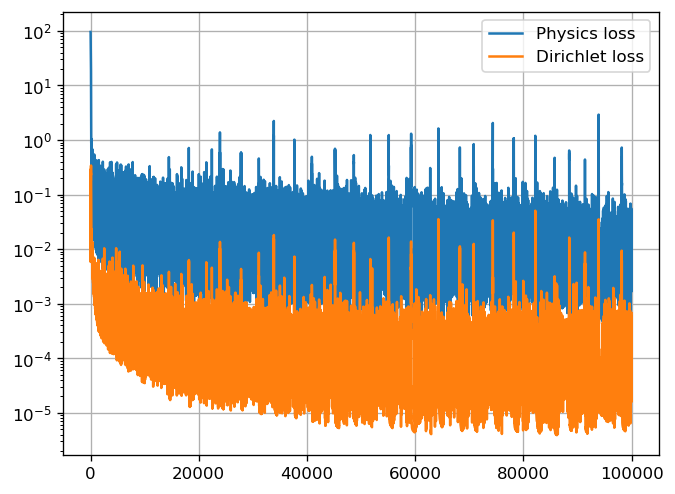

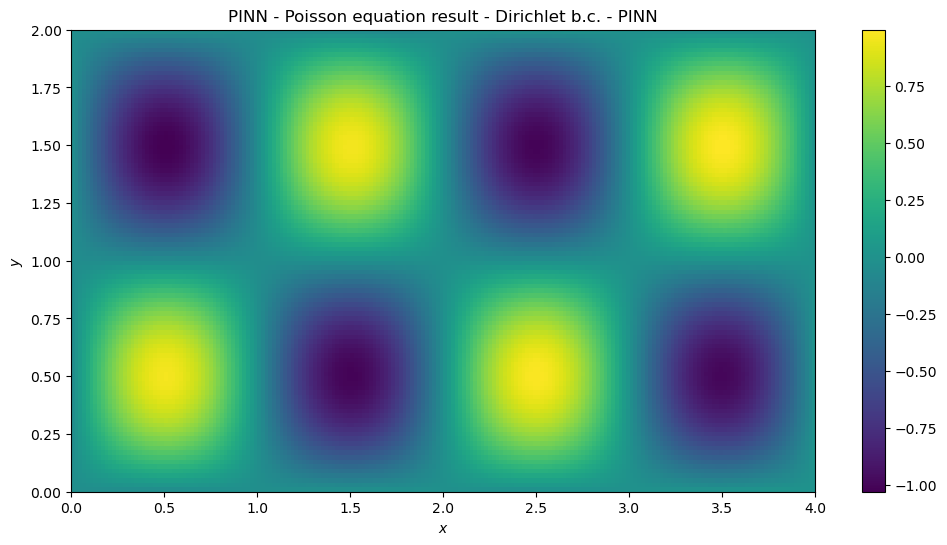

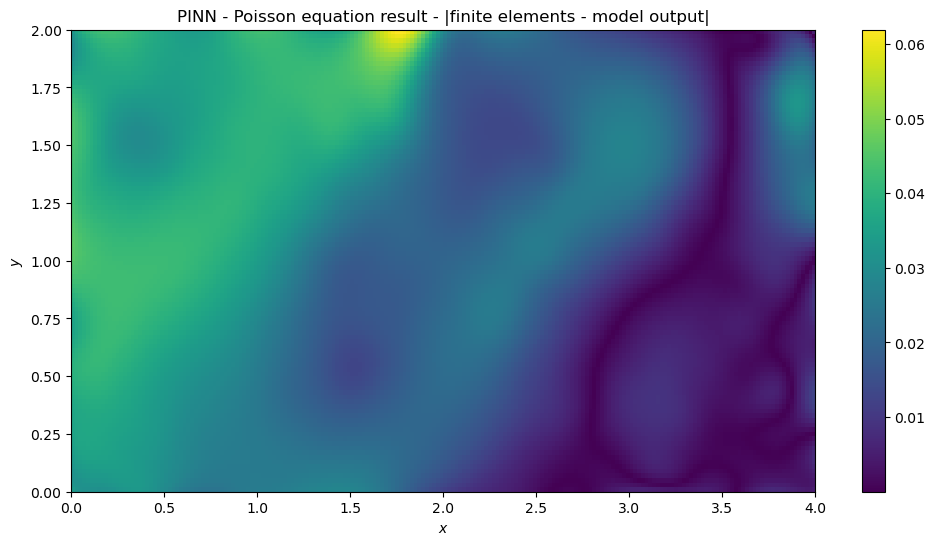

In [5]:

plt.figure(dpi= 120)
plt.semilogy(trial_PINN.epochs, trial_PINN.physics_losses, label = "Physics loss")
plt.semilogy(trial_PINN.epochs, trial_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = trial_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(12, 6))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - Dirichlet b.c. - PINN')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson_pinn.png')
plt.show()


plt.figure(figsize=(12, 6))
plt.imshow(np.abs(res - res_finite_elements), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - |finite elements - model output|')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/difference_FE_PINN_poisson.png')
plt.show()

pretty large values for both losses, especially the physics loss? 

**TO DO: tests varying dimensions and number of collocation and boundary points. When best convergence and overall results?**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

# now try solving the heat equations in 2 spatial dimensions + time 

# initial temperature is 100 inside the geometry (square of side 1), temperature is set to 100 °C on the edge
# work on timespan from 0 to 1
heat_PINN = PINN_heat_2d(48, lambda x: 0, lambda x: 100, alpha = 1)
heat_PINN.set_collocation_points(5000,(0,1),(0,1),(0,1))
heat_PINN.compute_initial_values(2000,(0,1),(0,1),0)
heat_PINN.compute_boundary_values(2000,(0,1),(0,1),(0,1))
heat_PINN.compute_physics_loss()

heat_PINN.train(20000)

Epoch [1000/20000], Loss: 50000.0000
Epoch [2000/20000], Loss: 50000.0000
Epoch [3000/20000], Loss: 50000.0000
Epoch [4000/20000], Loss: 5231.9263
Epoch [5000/20000], Loss: 1457.8346
Epoch [6000/20000], Loss: 1379.3984
Epoch [7000/20000], Loss: 870.9490
Epoch [8000/20000], Loss: 923.6694
Epoch [9000/20000], Loss: 605.8707
Epoch [10000/20000], Loss: 1352.3964
Epoch [11000/20000], Loss: 652.1085
Epoch [12000/20000], Loss: 2300.0830
Epoch [13000/20000], Loss: 726.5372
Epoch [14000/20000], Loss: 644.9691
Epoch [15000/20000], Loss: 395.9544
Epoch [16000/20000], Loss: 478.7878
Epoch [17000/20000], Loss: 1230.3402
Epoch [18000/20000], Loss: 575.6121
Epoch [19000/20000], Loss: 200.3812
Epoch [20000/20000], Loss: 243.9032


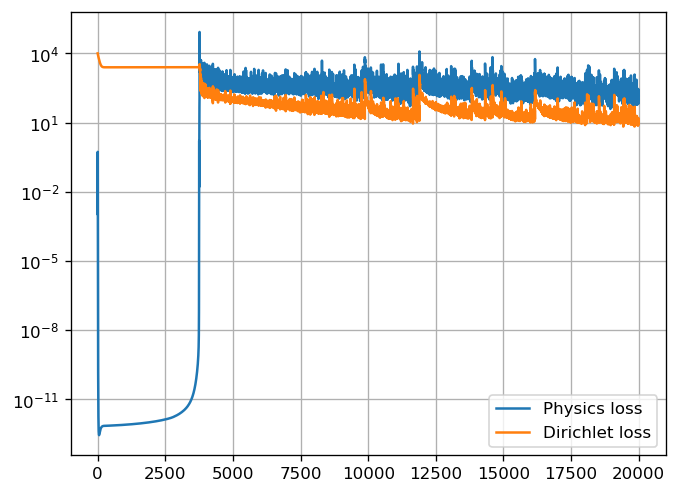

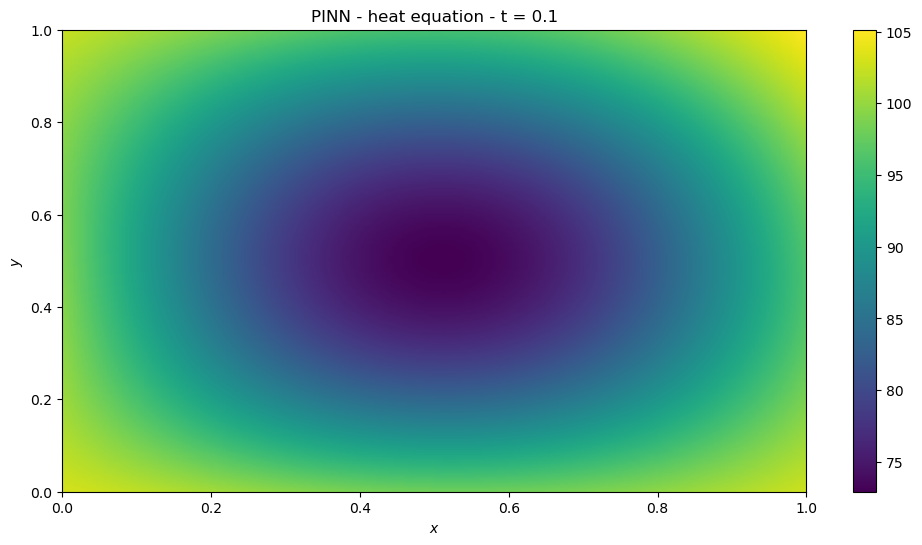

In [9]:
plt.figure(dpi= 120)
plt.semilogy(heat_PINN.epochs, heat_PINN.physics_losses, label = "Physics loss")
plt.semilogy(heat_PINN.epochs, heat_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()


t_check = 0.1
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)
# compute solution at t = 1
with torch.no_grad():
    u_pred = heat_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(12, 6))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()


**Now compare with finite elements (implicit midpoint rule for time evolution)**

Mass matrix initialization completed
Stiffness matrix initialization completed
Mass matrix initialization completed
Stiffness matrix initialization completed


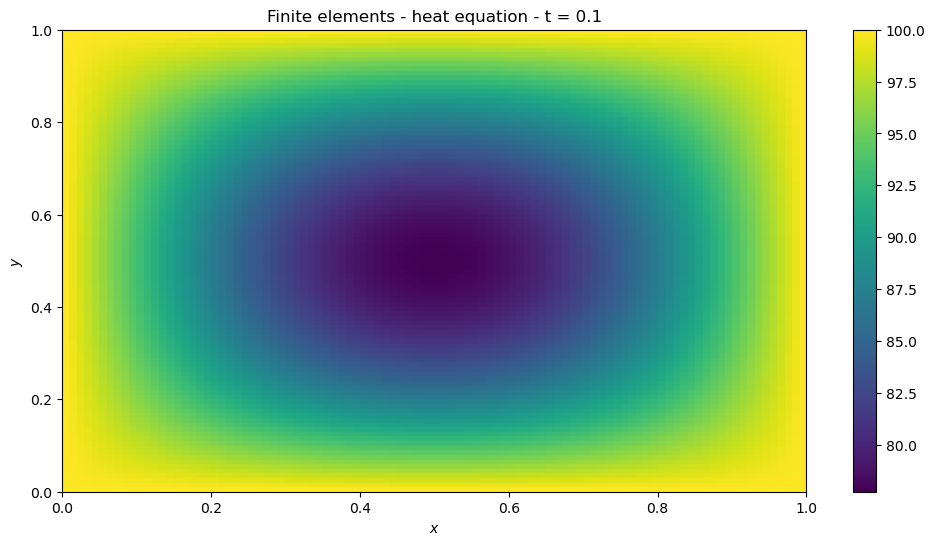

In [ ]:
# now compare with finite elements. Implicit midpoint rule (Crank-Nicolson) for time evolution


# grid:
Nx = Ny = 100
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
u0 = np.zeros(Nx*Ny)
# set initial conditions
for i in [0, Nx-1]:
    for j in range(0, Ny):
                u0[Ny*i + j] = 100
for j in [0, Ny-1]:
    for i in range(1, Nx - 1):
                u0[Ny*i + j] = 100
u = u0.copy()

# prepare the simulation 
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

steps = 200
times, dt = np.linspace(0, 0.1, steps, retstep = True)
alpha = 1

# Build matrices once before the time loop (expensive to rebuild every step)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

M = mymesh.M.tocsr()
S = mymesh.S.tocsr()
# Precompute LHS matrix needed for the implicit midpoint rule — it stays constant over the timestep iteration
LHS = (M + (dt * alpha / 2) * S).tolil()

# Apply boundary conditions to LHS once (zero row, set diagonal to 1)
bc_indices = []
for i in [0, Nx - 1]:
    for j in range(0, Ny):
        bc_indices.append(Ny * i + j)
for j in [0, Ny - 1]:
    for i in range(1, Nx - 1):
        bc_indices.append(Ny * i + j)
bc_indices = list(set(bc_indices))
for idx in bc_indices:
    LHS[idx, :] = 0
    LHS[idx, idx] = 1
LHS = LHS.tocsr()  # convert once for efficient solving

for t in times:
    # fompute RHS: (M - dt*alpha/2 * S) * u
    RHS_vec = (M - (dt * alpha / 2) * S).dot(u)

    # apply boundary conditions to RHS
    for idx in bc_indices:
        RHS_vec[idx] = 100

    # finally, solve the linear system
    u = spsolve(LHS, RHS_vec)

u = u.reshape((Nx, Ny)).transpose()

# plot the results
plt.figure(figsize=(12, 6))
plt.imshow(u, cmap='viridis', origin='lower', aspect='auto', extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(f'Finite elements - heat equation - t = {t_check}')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_finite_elements.png')
plt.show()

**things to try for PINN**
- smarter choice of the position of the collocation points ? especially for small alpha, they should maybe be desner around the boundary, where the temperature gradients are steeper. 
- in general, it may be a clever choice to first train on smaller times and only then on later times. also look up "residual based adaptive sampling"
- PINN results less good in the corners. Add more points there?
also, maybe make training faster by using GPU

At the beginning the physics loss drops while the Dirichlet loss does not. Probable cause: at the beginning the PINN solution basically converges to the trivial solution. To be checked.